# $visit_n - visit_1 \rightarrow fatigue_n - fatigue_1$
$\Delta visit \rightarrow \Delta fatigue$ \
Finds difference from **first** visit to current visit **using daily DMOs**

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.train import TransformerRegressionXV
from src.core.data_transforms import Transform


import torch

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [18]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam, AdamW

config = ModelConfig(
    name="transformer_regression",
    model_type="Transformer",
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
    
    #not used
    input_size=25,
    hidden_size=128,
    num_layers=1,
    output_size=1,
)
config.notes = "None"

transformer_config = {
    "input_features": 168,
    "d_model": 32,
    "nheads": 4,
    "num_layers": 1,
    "dim_feedforward": 4*32,
    "output_size": 1,
    "dropout": 0.1
}

In [5]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [ ]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [8]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [9]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [10]:
print(dmo_data.shape)

torch.Size([428, 4, 7, 24])


In [11]:
# Min max normalise the labels globally

label_normaliser = Normaliser(MinMaxScaler())
dmo_labels = label_normaliser.scaler_fit_transform(dmo_labels)

In [12]:
def format_input_data_delta_visit(input_data):
    if len(input_data.shape) < 4:
            input_data = input_data.unsqueeze(dim=2)

    patients, visits, days, features = input_data.shape

    delta_visits = torch.zeros(patients, visits - 1, days, features)
    for patient in range(patients):
        reference_visit = input_data[patient, 0]
        for visit in range(visits - 1):
            updated_visit = input_data[patient, visit + 1] - reference_visit
            delta_visits[patient, visit] = updated_visit 

    return delta_visits

def format_label_data_delta_visit(label_data):
    patients, visits, labels = label_data.shape
    
    delta_labels = torch.zeros(patients, (visits - 1), labels)
    for patient in range(patients):
        reference_label = label_data[patient, 0]
        delta_visits = label_data[patient, 1:] - reference_label

        delta_labels[patient] = delta_visits

    return delta_labels
    # return delta_labels


In [13]:
dmo_data = format_input_data_delta_visit(dmo_data)
dmo_labels = format_label_data_delta_visit(dmo_labels)

In [14]:
dmo_data = dmo_data.flatten(start_dim=2, end_dim=3)

In [19]:
xv_trainer = TransformerRegressionXV(
    dmo_data, dmo_labels, config, transformer_config, device, k=K_FOLDS
)
prediction, actual = xv_trainer.train_cross_validation()

Testing loss: 0.03846795887996753
Testing loss: 0.03542286281784376
Testing loss: 0.037346931329617895
Testing loss: 0.03455889721711477
Testing loss: 0.0399283180013299


In [20]:
prediction = torch.concatenate(prediction).flatten().reshape(dmo_labels.shape)
prediction = label_normaliser.scaler_inverse_labels(prediction).flatten()
prediction.shape

torch.Size([1284])

In [21]:
actual = torch.concatenate(actual).flatten().reshape(dmo_labels.shape)
actual = label_normaliser.scaler_inverse_labels(actual).flatten()
actual.shape

torch.Size([1284])

In [22]:
print(xv_trainer.R2_values)

[-0.36881232261657715, -0.2504991292953491, -0.5098484754562378, -0.2840454578399658, -0.40453243255615234]


All metrics: {'accuracy': 0.012461059190031152, 'Mean Squared Error': 47.15976333618164, 'Mean Absolute Error': 5.35236930847168, 'R^2': -0.3363927227392951}


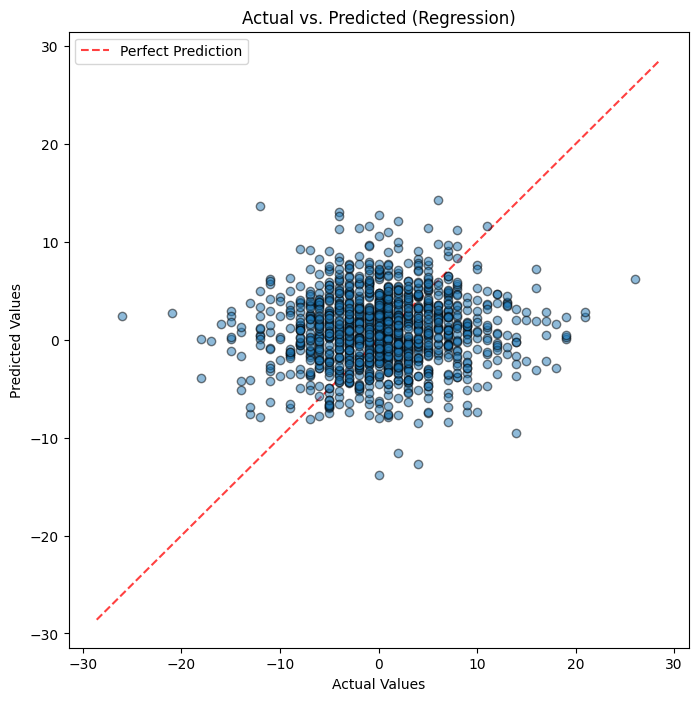

In [23]:
from src.evaluation import Evaluation

evaluation = Evaluation(prediction, actual)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
